In [1]:
import cmdstanpy
#cmdstanpy.install_cmdstan()

import numpy as np
import scipy as sp
import cmdstanpy as csp
from scipy.special import expit

seed = 583883
D = 6
N = 1500
mu_x_OH = -1
mu_x_NY  = 1
B = 10_000
h = 0.04

rng = np.random.default_rng(seed)

# generate single parameter vectors
beta = rng.normal(loc=0.0, scale=1.0, size=D)
print(f"{beta=}")

# generate Ohio data from parameters
x_OH = rng.normal(loc=-1.0, scale=1.0, size=(N, D))
y_OH = rng.binomial(n=1, p = expit(x_OH @ beta))

# generate NY data from parameters
x_NY = rng.normal(loc=1.0, scale=1.0, size=(N, D))
y_NY = rng.binomial(n=1, p = expit(x_NY @ beta))
print(f"{np.mean(y_NY)=}")  # shouldn't be too extreme

# fit OH data with simple logistic regression
data_OH = {'N': N, 'D': D, 'x': x_OH, 'y': y_OH }
model_OH = csp.CmdStanModel(stan_file='flat-logistic.stan')
fit_OH = model_OH.sample(data=data_OH, chains=4, iter_sampling=B // 4, seed=seed)
print(fit_OH.summary())
beta_OH_draws = fit_OH.stan_variable('beta')

# fit NY data with empirical prior from posterior of OH data
data_NY = {'N': N, 'D': D, 'x': x_NY, 'y': y_NY,
               'h': h, 'B': B, 'beta0': beta_OH_draws }
model_NY = csp.CmdStanModel(stan_file='empirical-logistic.stan')
fit_NY = model_NY.sample(data=data_NY, chains=4, iter_warmup=500, iter_sampling=500, seed=seed)
print(fit_NY.summary())

import ot  # Python Optimal Transport library
from scipy.optimize import minimize
from scipy.stats import multivariate_normal

def fit_wasserstein_prior(posterior_draws, prior_family='mvn'):
    """
    Fit a parametric prior by minimizing Wasserstein distance
    to empirical posterior draws
    """
    D = posterior_draws.shape[1]

    if prior_family == 'mvn':
        # Optimize over multivariate normal parameters
        def objective(params):
            mu = params[:D]
            # Ensure positive definite covariance (Cholesky parameterization)
            L_vec = params[D:]
            L = np.zeros((D, D))
            L[np.triu_indices(D)] = L_vec
            Sigma = L @ L.T + 1e-6 * np.eye(D)  # Add small regularization

            # Sample from fitted distribution
            fitted_samples = multivariate_normal.rvs(mu, Sigma, size=len(posterior_draws))

            # Compute Wasserstein-2 distance
            cost_matrix = ot.dist(posterior_draws, fitted_samples, metric='euclidean')
            W2_distance = ot.emd2([], [], cost_matrix)
            return W2_distance

        # Initialize with sample mean and covariance
        init_mu = np.mean(posterior_draws, axis=0)
        init_cov = np.cov(posterior_draws.T)
        L_init = np.linalg.cholesky(init_cov)
        init_params = np.concatenate([init_mu, L_init[np.triu_indices(D)]])

        # Optimize
        result = minimize(objective, init_params, method='L-BFGS-B')

        # Extract optimized parameters
        mu_opt = result.x[:D]
        L_vec_opt = result.x[D:]
        L_opt = np.zeros((D, D))
        L_opt[np.triu_indices(D)] = L_vec_opt
        Sigma_opt = L_opt @ L_opt.T

        return mu_opt, Sigma_opt

# After fitting OH model:
beta_OH_draws = fit_OH.stan_variable('beta')

# Fit Wasserstein-optimal prior
mu_prior, Sigma_prior = fit_wasserstein_prior(beta_OH_draws)

# Use in Stan model (modified version)
data_NY_wass = {
    'N': N, 'D': D, 'x': x_NY, 'y': y_NY,
    'mu_prior': mu_prior, 'Sigma_prior': Sigma_prior
}

DEBUG:cmdstanpy:found newer exe file, not recompiling
DEBUG:cmdstanpy:cmd: /content/flat-logistic info
cwd: None


beta=array([ 0.32292202, -1.67712417,  0.80797451,  0.23766868,  0.86741335,
       -1.506818  ])
np.mean(y_NY)=np.float64(0.368)


DEBUG:cmdstanpy:input tempfile: /tmp/tmpy2c2cbr3/8cdrs6bq.json
03:40:58 - cmdstanpy - INFO - CmdStan start processing
INFO:cmdstanpy:CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

...

DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:idx 1
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/content/empirical-logistic', 'id=2', 'random', 'seed=583883', 'data', 'file=/tmp/tmpy2c2cbr3/rp0etn6c.json', 'output', 'file=/tmp/tmpy2c2cbr3/empirical-logisticv7zdlbnb/empirical-logistic-20250514034119_2.csv', 'method=sample', 'num_samples=500', 'num_warmup=500', 'algorithm=hmc', 'adapt', 'engaged=1']
DEBUG:cmdstanpy:CmdStan args: ['/content/empirical-logistic', 'id=1', 'random', 'seed=583883', 'data', 'file=/tmp/tmpy2c2cbr3/rp0etn6c.json', 'output', 'file=/tmp/tmpy2c2cbr3/empirical-logisticv7zdlbnb/empirical-logistic-20250514034119_1.csv', 'method=sample', 'num_samples=500', 'num_warmup=500', 'algorithm=hmc', 'adapt', 'engaged=1']
DEBUG:cmdstanpy:idx 2
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/content/empirical-logistic', 'id=3', 'random', 'seed=583883', 'data', 'file=/tmp/tm

03:43:39 - cmdstanpy - INFO - CmdStan done processing.
INFO:cmdstanpy:CmdStan done processing.
DEBUG:cmdstanpy:runset
RunSet: chains=4, chain_ids=[1, 2, 3, 4], num_processes=4
 cmd (chain 1):
	['/content/empirical-logistic', 'id=1', 'random', 'seed=583883', 'data', 'file=/tmp/tmpy2c2cbr3/rp0etn6c.json', 'output', 'file=/tmp/tmpy2c2cbr3/empirical-logisticv7zdlbnb/empirical-logistic-20250514034119_1.csv', 'method=sample', 'num_samples=500', 'num_warmup=500', 'algorithm=hmc', 'adapt', 'engaged=1']
 retcodes=[0, 0, 0, 0]
 per-chain output files (showing chain 1 only):
 csv_file:
	/tmp/tmpy2c2cbr3/empirical-logisticv7zdlbnb/empirical-logistic-20250514034119_1.csv
 console_msgs (if any):
	/tmp/tmpy2c2cbr3/empirical-logisticv7zdlbnb/empirical-logistic-20250514034119_0-stdout.txt
DEBUG:cmdstanpy:Chain 1 console:
method = sample (Default)
  sample
    num_samples = 500
    num_warmup = 500
    save_warmup = false (Default)
    thin = 1 (Default)
    adapt
      engaged = true (Default)
      ga


               Mean      MCSE    StdDev       MAD          5%         50%  \
lp__    -559.231000  0.052517  1.670540  1.512990 -562.479000 -558.881000   
beta[1]    0.350303  0.001256  0.053163  0.055772    0.264625    0.349386   
beta[2]   -1.684520  0.002128  0.072740  0.073189   -1.806480   -1.683590   
beta[3]    0.816993  0.001509  0.058009  0.055932    0.720248    0.818284   
beta[4]    0.308557  0.001222  0.052301  0.054825    0.222648    0.310081   
beta[5]    0.807412  0.001536  0.056870  0.057270    0.714319    0.807694   
beta[6]   -1.547500  0.002062  0.069704  0.068882   -1.664110   -1.546650   

                95%  ESS_bulk  ESS_tail     R_hat  
lp__    -557.139000   1042.35   1121.73  1.007360  
beta[1]    0.440071   1791.38   1473.59  1.000620  
beta[2]   -1.568570   1172.88   1269.70  1.001860  
beta[3]    0.910145   1522.17   1148.50  0.999944  
beta[4]    0.389971   1861.81   1350.30  1.001190  
beta[5]    0.902555   1385.68   1368.33  1.002960  
beta[6]   -1.43565

/usr/local/lib/python3.11/dist-packages/ot/lp/__init__.py:630: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  check_result(result_code)


KeyboardInterrupt: 

In [6]:
import cmdstanpy
#cmdstanpy.install_cmdstan()

import numpy as np
import scipy as sp
import cmdstanpy as csp
from scipy.special import expit

seed = 583883
D = 6
N = 1500
mu_x_OH = -1
mu_x_NY  = 1
B = 10_000
h = 0.04

rng = np.random.default_rng(seed)

# Closed‐form 2‐Wasserstein “projection” onto Gaussians: sample mean & covariance
def fit_wasserstein_prior(draws):
    """
    Returns the Gaussian (mu, Sigma) that minimizes W2 distance
    to the empirical measure of 'draws' via matching first two moments.
    """
    mu    = np.mean(draws, axis=0)
    Sigma = np.cov(draws, rowvar=False)
    return mu, Sigma


# After fitting the Ohio model:
beta_OH_draws = fit_OH.stan_variable('beta')  # shape (B, D)

# Fit the W2‐optimal Gaussian prior
mu_prior, Sigma_prior = fit_wasserstein_prior(beta_OH_draws)

# Prepare data for the next Stan model (NY with Gaussian prior)
data_NY_wass = {
    'N': N,
    'D': D,
    'x': x_NY,
    'y': y_NY,
    'mu_prior': mu_prior,
    'Sigma_prior': Sigma_prior
}

model_NY_wass = csp.CmdStanModel(stan_file='gaussian-prior-logistic.stan')
fit_NY_wass   = model_NY_wass.sample(data=data_NY_wass, chains=4, iter_warmup=500, iter_sampling=500, seed=seed)
print(fit_NY_wass.summary())

03:56:38 - cmdstanpy - INFO - compiling stan file /content/gaussian-prior-logistic.stan to exe file /content/gaussian-prior-logistic
INFO:cmdstanpy:compiling stan file /content/gaussian-prior-logistic.stan to exe file /content/gaussian-prior-logistic
DEBUG:cmdstanpy:cmd: make STANCFLAGS+=--filename-in-msg=gaussian-prior-logistic.stan /content/gaussian-prior-logistic
cwd: /root/.cmdstan/cmdstan-2.36.0
DEBUG:cmdstanpy:Console output:

--- Translating Stan model to C++ code ---
bin/stanc --filename-in-msg=gaussian-prior-logistic.stan --o=/content/gaussian-prior-logistic.hpp /content/gaussian-prior-logistic.stan

--- Compiling C++ code ---
g++ -std=c++17 -pthread -D_REENTRANT -Wno-sign-compare -Wno-ignored-attributes -Wno-class-memaccess      -I stan/lib/stan_math/lib/tbb_2020.3/include    -O3 -I src -I stan/src -I stan/lib/rapidjson_1.1.0/ -I lib/CLI11-1.9.1/ -I stan/lib/stan_math/ -I stan/lib/stan_math/lib/eigen_3.4.0 -I stan/lib/stan_math/lib/boost_1.84.0 -I stan/lib/stan_math/lib/sundi

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/content/gaussian-prior-logistic', 'id=1', 'random', 'seed=583883', 'data', 'file=/tmp/tmpy2c2cbr3/bvxaqii4.json', 'output', 'file=/tmp/tmpy2c2cbr3/gaussian-prior-logisticjvwo6wgf/gaussian-prior-logistic-20250514035712_1.csv', 'method=sample', 'num_samples=500', 'num_warmup=500', 'algorithm=hmc', 'adapt', 'engaged=1']
DEBUG:cmdstanpy:idx 1
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/content/gaussian-prior-logistic', 'id=2', 'random', 'seed=583883', 'data', 'file=/tmp/tmpy2c2cbr3/bvxaqii4.json', 'output', 'file=/tmp/tmpy2c2cbr3/gaussian-prior-logisticjvwo6wgf/gaussian-prior-logistic-20250514035712_2.csv', 'method=sample', 'num_samples=500', 'num_warmup=500', 'algorithm=hmc', 'adapt', 'engaged=1']
DEBUG:cmdstanpy:idx 2
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/content/gaussian-prior-logistic', 'id=3', 'random', '

03:57:15 - cmdstanpy - INFO - CmdStan done processing.
INFO:cmdstanpy:CmdStan done processing.
DEBUG:cmdstanpy:runset
RunSet: chains=4, chain_ids=[1, 2, 3, 4], num_processes=4
 cmd (chain 1):
	['/content/gaussian-prior-logistic', 'id=1', 'random', 'seed=583883', 'data', 'file=/tmp/tmpy2c2cbr3/bvxaqii4.json', 'output', 'file=/tmp/tmpy2c2cbr3/gaussian-prior-logisticjvwo6wgf/gaussian-prior-logistic-20250514035712_1.csv', 'method=sample', 'num_samples=500', 'num_warmup=500', 'algorithm=hmc', 'adapt', 'engaged=1']
 retcodes=[0, 0, 0, 0]
 per-chain output files (showing chain 1 only):
 csv_file:
	/tmp/tmpy2c2cbr3/gaussian-prior-logisticjvwo6wgf/gaussian-prior-logistic-20250514035712_1.csv
 console_msgs (if any):
	/tmp/tmpy2c2cbr3/gaussian-prior-logisticjvwo6wgf/gaussian-prior-logistic-20250514035712_0-stdout.txt
DEBUG:cmdstanpy:Chain 1 console:
method = sample (Default)
  sample
    num_samples = 500
    num_warmup = 500
    save_warmup = false (Default)
    thin = 1 (Default)
    adapt
    


               Mean      MCSE    StdDev       MAD          5%         50%  \
lp__    -568.833000  0.061184  1.775250  1.637530 -572.075000 -568.518000   
beta[1]    0.352418  0.001256  0.049502  0.048350    0.271975    0.351888   
beta[2]   -1.696680  0.002096  0.075393  0.072381   -1.818390   -1.698950   
beta[3]    0.824647  0.001493  0.057310  0.057457    0.732214    0.822308   
beta[4]    0.301689  0.001300  0.050560  0.050508    0.216780    0.301548   
beta[5]    0.808698  0.001430  0.056148  0.054268    0.714924    0.808041   
beta[6]   -1.550370  0.001959  0.071111  0.067636   -1.671050   -1.548620   

                95%  ESS_bulk  ESS_tail     R_hat  
lp__    -566.585000   881.262   1143.34  1.002360  
beta[1]    0.434444  1584.370   1544.86  1.001480  
beta[2]   -1.570150  1307.350   1407.69  0.999047  
beta[3]    0.922475  1502.040   1410.28  1.002310  
beta[4]    0.386601  1520.230   1296.52  1.000290  
beta[5]    0.901743  1563.190   1176.63  1.000660  
beta[6]   -1.43652

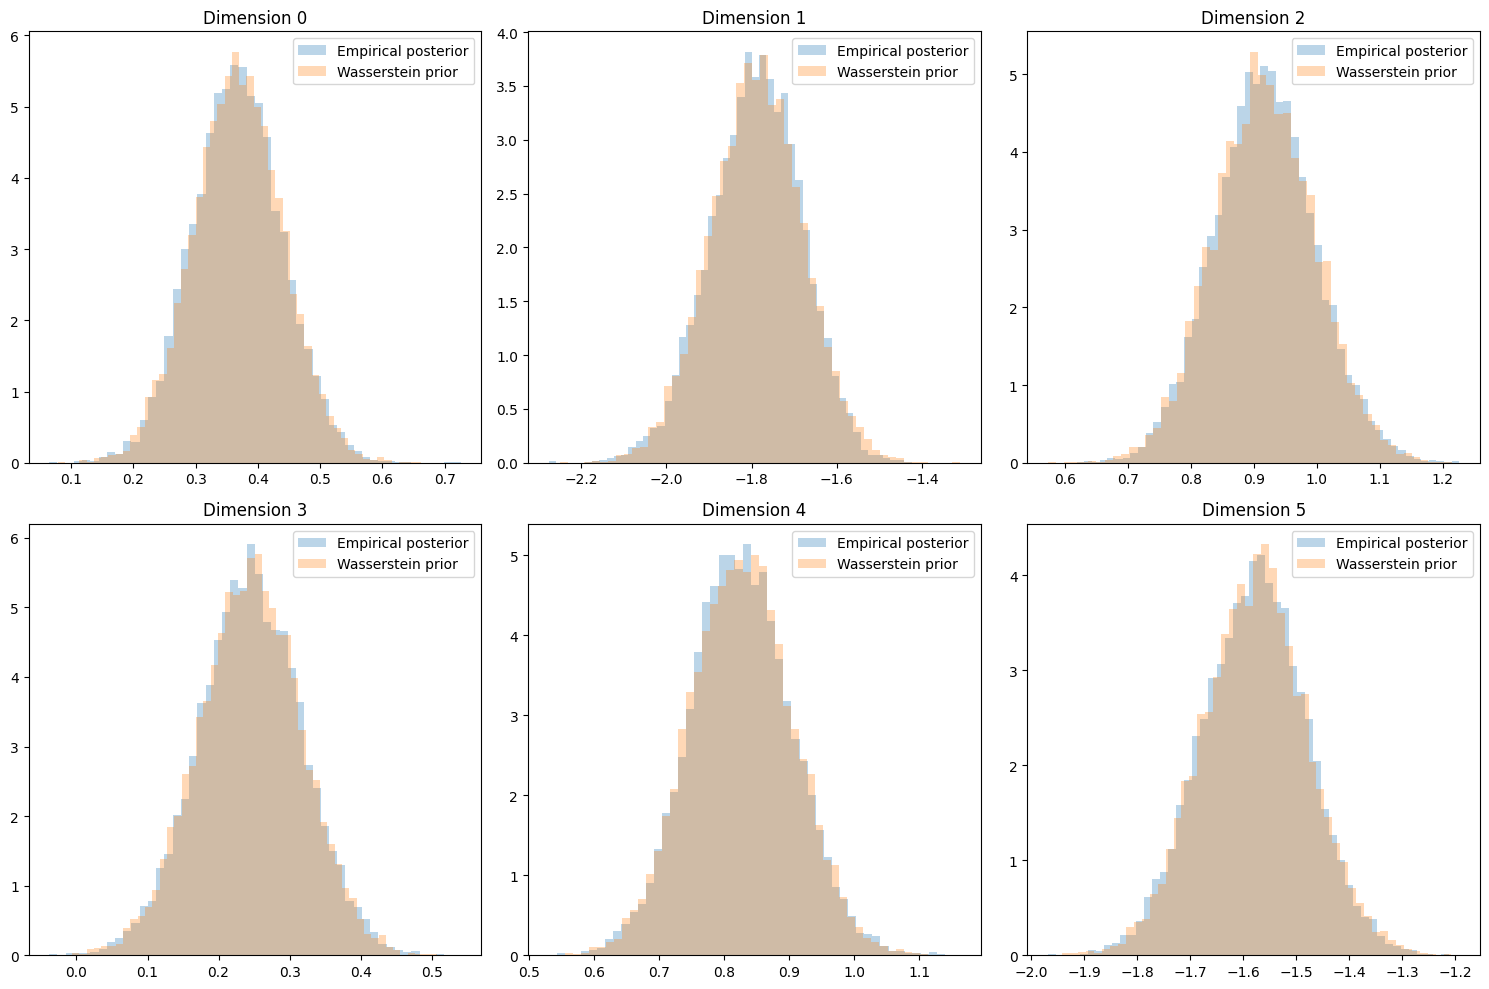

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_prior_comparison(empirical_draws, mu_wass, Sigma_wass, h_kde):
    """Compare KDE vs Wasserstein approximations visually"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    for dim in range(min(6, D)):
        ax = axes[dim // 3, dim % 3]

        # Plot empirical posterior
        ax.hist(empirical_draws[:, dim], bins=50, alpha=0.3,
                label='Empirical posterior', density=True)

        # Plot KDE approximation
        x_range = np.linspace(empirical_draws[:, dim].min(),
                             empirical_draws[:, dim].max(), 100)
        kde_samples = rng.normal(mu_wass[dim], np.sqrt(Sigma_wass[dim, dim]), 10000)
        ax.hist(kde_samples, bins=50, alpha=0.3,
                label='Wasserstein prior', density=True)

        ax.set_title(f'Dimension {dim}')
        ax.legend()

    plt.tight_layout()
    plt.show()

# After fitting both methods
plot_prior_comparison(beta_OH_draws, mu_prior, Sigma_prior, h)

95% credible interval coverage: 1.000


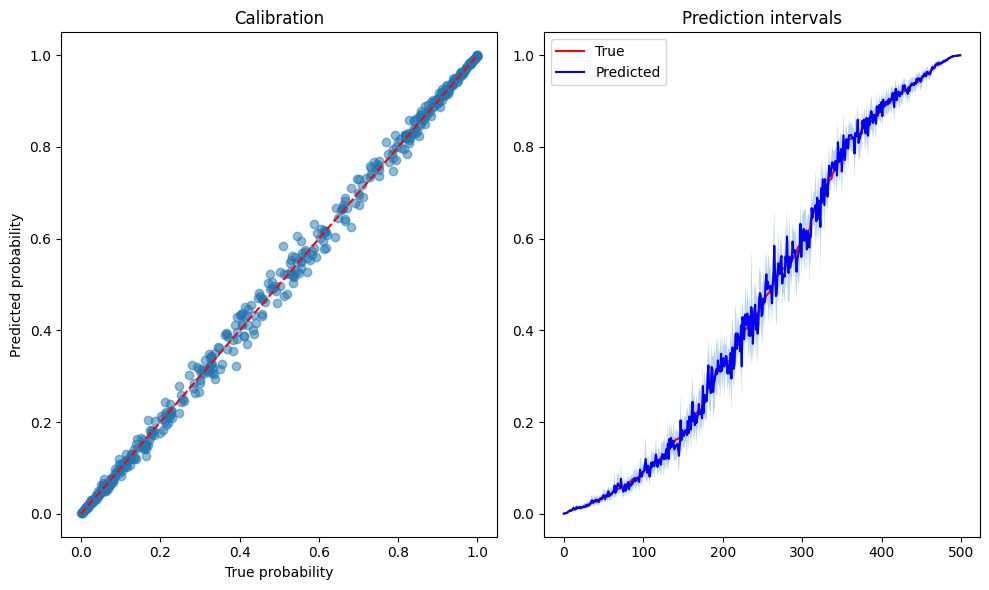

In [8]:
def posterior_predictive_check(x_test, beta_draws, beta_true):
    """Check if posterior draws generate reasonable predictions"""
    # Generate predictions from posterior draws
    pred_probs = []
    for beta_draw in beta_draws[-1000:]:  # Use last 1000 draws
        pred_probs.append(expit(x_test @ beta_draw))
    pred_probs = np.array(pred_probs)

    # True probabilities
    true_probs = expit(x_test @ beta_true)

    # Check coverage
    pred_mean = np.mean(pred_probs, axis=0)
    pred_lower = np.percentile(pred_probs, 2.5, axis=0)
    pred_upper = np.percentile(pred_probs, 97.5, axis=0)

    coverage = np.mean((true_probs >= pred_lower) & (true_probs <= pred_upper))
    print(f"95% credible interval coverage: {coverage:.3f}")

    # Plot calibration
    plt.figure(figsize=(10, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(true_probs, pred_mean, alpha=0.5)
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel('True probability')
    plt.ylabel('Predicted probability')
    plt.title('Calibration')

    # Plot prediction intervals
    plt.subplot(1, 2, 2)
    order = np.argsort(true_probs)
    plt.fill_between(range(len(order)), pred_lower[order], pred_upper[order], alpha=0.3)
    plt.plot(true_probs[order], 'r-', label='True')
    plt.plot(pred_mean[order], 'b-', label='Predicted')
    plt.legend()
    plt.title('Prediction intervals')
    plt.tight_layout()
    plt.show()

# Test all three methods
x_test = rng.normal(loc=0.0, scale=1.0, size=(500, D))
posterior_predictive_check(x_test, fit_NY.stan_variable('beta'), beta)